# Setting up a simple example using an articulated robot

In [1]:
import sys
from pathlib import Path


# Define paths
REPO_ROOT = Path.cwd().parent               # Repo root (ikp-sbl)
LECTURE_EXAMPLES = REPO_ROOT / "lecture_examples"

# Add BOTH to sys.path
for path in [str(REPO_ROOT), str(LECTURE_EXAMPLES)]:
    if path not in sys.path:
        sys.path.insert(0, path)

from lecture_examples.IPPlanarManipulator import PlanarJoint, PlanarRobot
from lecture_examples.IPEnvironmentKin import KinChainCollisionChecker, planarRobotVisualize, animateSolution
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon, LineString
from shapely import plotting

from planners.SBL import SBL
from modules import IPVISsbl

obst = dict()
obst["obs1"] = LineString([(-2, 0), (-0.8, 0)]).buffer(0.5)
obst["obs2"] = LineString([(2, 0), (2, 1)]).buffer(0.2)
obst["obs3"] = LineString([(-1, 2), (1, 2)]).buffer(0.1)

# 2-DoF

In [2]:
r = PlanarRobot(n_joints=2)
environment = KinChainCollisionChecker(r, obst,fk_resolution=.2)

Draw start and goal position of robot within the environment

In [3]:
start_joint_pos = [2.0, 0.5]
end_joint_pos = [-2.0, -0.5]

start = start_joint_pos
goal  = end_joint_pos

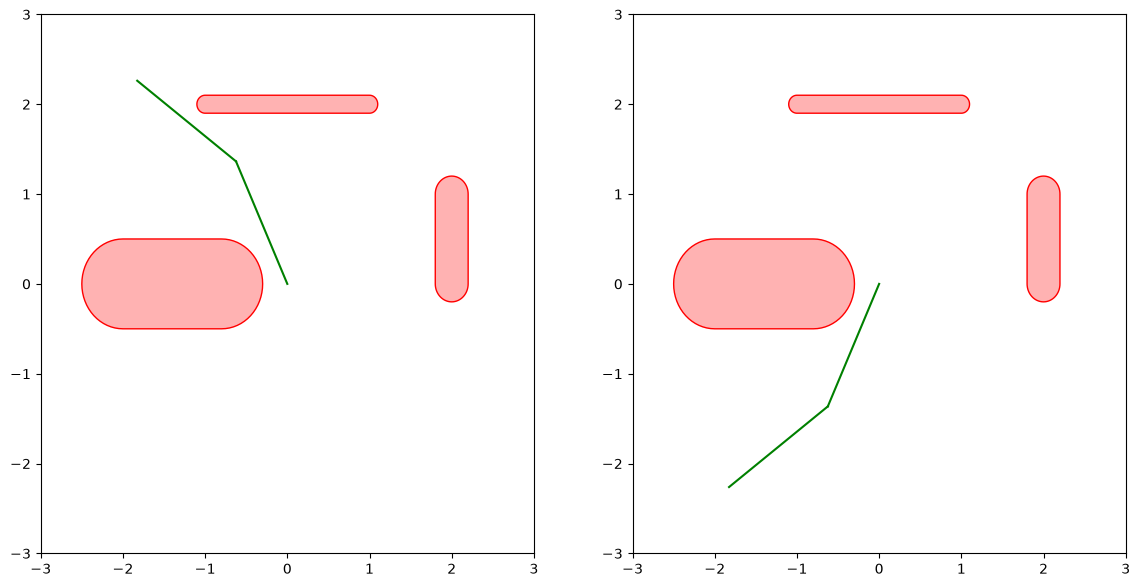

In [4]:
fig_local = plt.figure(figsize=(14, 7))
## left figure for robot start position
ax1 = fig_local.add_subplot(1, 2, 1)
ax1.set_xlim([-3,3])
ax1.set_ylim([-3,3])
environment.drawObstacles(ax1, True)
r.move(start)
planarRobotVisualize(r, ax1)
## right figure robot goal position
ax2 = fig_local.add_subplot(1, 2, 2)
ax2.set_xlim([-3,3])
ax2.set_ylim([-3,3])
environment.drawObstacles(ax2, True)
r.move(goal)
planarRobotVisualize(r, ax2)

In [5]:
config = {} #BidirectionalSBL.DEFAULT_CONFIG.copy()
config["iterations"] = 1000
config["eta"] = 2.0

planner = SBL(environment)


In [6]:
## plan path from start to goal
solution = planner.planPath(start, goal, config)
print(solution)

  0%|          | 0/1000 [00:00<?, ?it/s]

  3%|▎         | 34/1000 [00:10<04:44,  3.39it/s]

[Node(start, [2.  0.5]), Node(start, [1.74688441 1.60300928]), Node(start, [1.39945504 1.74413984]), Node(start, [1.26401845 1.87380548]), Node(start, [0.89153248 1.83045569]), Node(goal, [-0.03011792  2.62840638]), Node(goal, [-0.64143804  2.17339432]), Node(goal, [-0.78018289  1.86006137]), Node(goal, [-0.96757101  1.853585  ]), Node(goal, [-1.79412872  0.60186525]), Node(goal, [-1.97589466 -0.12577556]), Node(goal, [-2.  -0.5])]


In [7]:
animateSolution(planner, environment, solution, IPVISsbl.sblVisualize)

In [8]:
# 4-DoF

In [9]:
r = PlanarRobot(n_joints=4)
limits = [[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14]]
environment = KinChainCollisionChecker(r, obst, limits=limits, fk_resolution=.2)
planner = SBL(environment)

In [10]:
start_joint_pos = [2.0, 0.5, 0.5, 0.5]
end_joint_pos = [-2.0, -0.5, -0.5, -0.5]
start = [start_joint_pos]
goal  = [end_joint_pos]

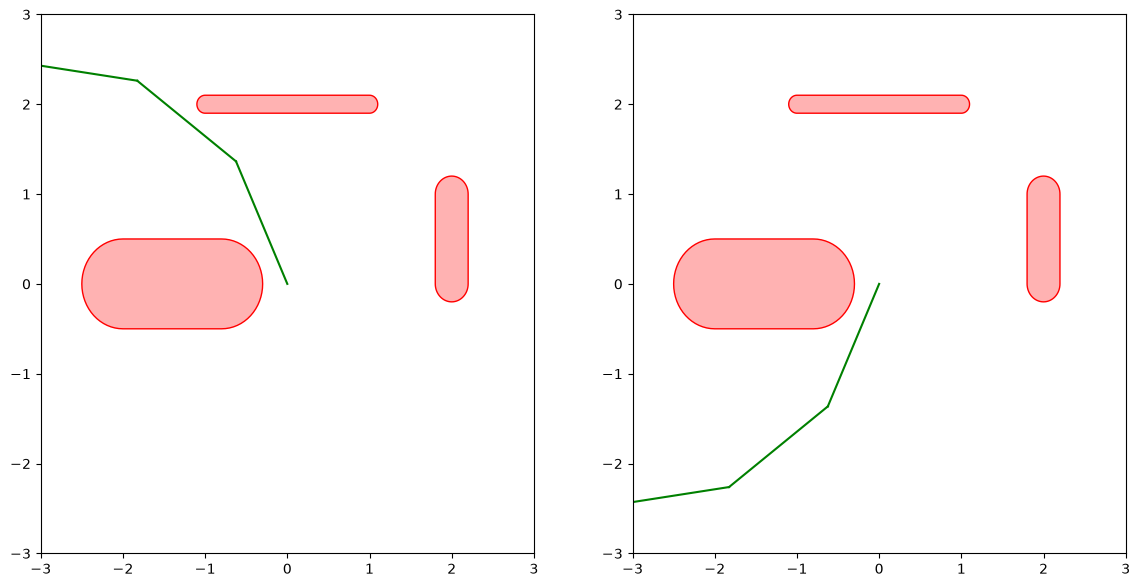

In [11]:
fig_local = plt.figure(figsize=(14, 7))
## left figure for robot start position
ax1 = fig_local.add_subplot(1, 2, 1)
ax1.set_xlim([-3,3])
ax1.set_ylim([-3,3])
environment.drawObstacles(ax1, True)
r.move(start_joint_pos)
planarRobotVisualize(r, ax1)
## right figure robot goal position
ax2 = fig_local.add_subplot(1, 2, 2)
ax2.set_xlim([-3,3])
ax2.set_ylim([-3,3])
environment.drawObstacles(ax2, True)
r.move(end_joint_pos)
planarRobotVisualize(r, ax2)

In [12]:
solution = planner.planPath(start, goal, config)
print(solution)

 48%|████▊     | 484/1000 [05:28<05:49,  1.48it/s]

[Node(start, [2.  0.5 0.5 0.5]), Node(start, [2.0398795  0.62230073 0.36822882 0.4647188 ]), Node(start, [2.04303691 1.05893206 0.58277734 0.30740406]), Node(start, [1.48160381 1.33147855 0.91965971 0.06343366]), Node(start, [ 1.48887098  1.39657113  0.9347116  -0.00193182]), Node(start, [ 1.41069491  1.41268697  0.93872724 -0.05093915]), Node(start, [ 1.36902185  1.4982418   0.98376194 -0.09058576]), Node(start, [ 1.37487005  1.68720913  0.7698497  -0.20599146]), Node(start, [ 0.8887335   2.28135234  0.12065665 -1.35417282]), Node(start, [ 0.78388305  2.32683374  0.25174659 -1.42424067]), Node(start, [ 0.37591037  2.54821263  0.1604588  -1.40206732]), Node(start, [ 0.29189173  2.51865682  0.09657506 -1.3767209 ]), Node(start, [ 0.23729768  2.44675085  0.08236434 -1.35583696]), Node(start, [-0.73112233  3.07412582  0.22856187 -0.40863602]), Node(start, [-0.92999337  3.05658524  0.43229002 -0.27175483]), Node(start, [-0.82633404  3.00942373  0.49171894 -0.0870287 ]), Node(start, [-0.129

In [ ]:
animation_solution = [node.coordinates for node in solution]
animateSolution(planner, environment, animation_solution, IPVISsbl.sblVisualize)

## 6-DoF

In [ ]:
r = PlanarRobot(n_joints=6)
limits = [[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14]]
environment = KinChainCollisionChecker(r, obst, limits=limits, fk_resolution=.2)
planner = BidirectionalSBL(environment)

In [ ]:
start_joint_pos = [2.0, 0.5, 0.5, 0.5, 0.5, 0.5]
end_joint_pos = [-2.0, -0.5, -0.5, -0.5, -0.5, -0.5]
start = [start_joint_pos]
goal  = [end_joint_pos]

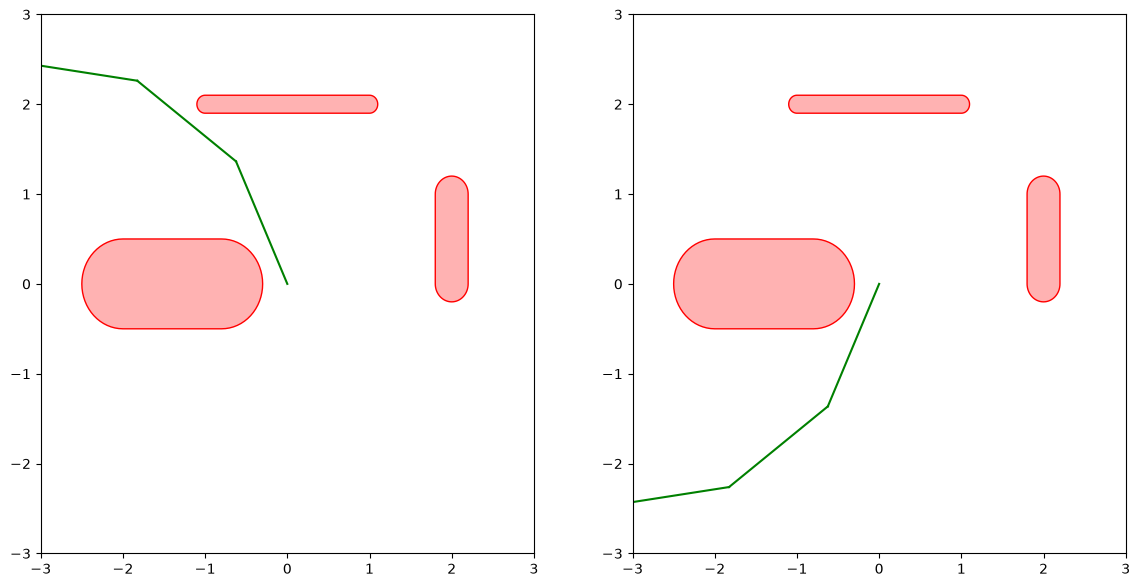

In [ ]:
fig_local = plt.figure(figsize=(14, 7))
## left figure for robot start position
ax1 = fig_local.add_subplot(1, 2, 1)
ax1.set_xlim([-3,3])
ax1.set_ylim([-3,3])
environment.drawObstacles(ax1, True)
r.move(start_joint_pos)
planarRobotVisualize(r, ax1)
## right figure robot goal position
ax2 = fig_local.add_subplot(1, 2, 2)
ax2.set_xlim([-3,3])
ax2.set_ylim([-3,3])
environment.drawObstacles(ax2, True)
r.move(end_joint_pos)
planarRobotVisualize(r, ax2)

In [ ]:
solution = planner.planPath(start, goal, config)
print(solution)

 50%|█████     | 504/1000 [19:31<10:06,  1.22s/it]  

In [ ]:
animateSolution(planner, environment, solution, IPVISsbl.sblVisualize)